In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/Smart_Hospital_Synthetic_Dataset_3000.csv')

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'Smart_Hospital_Synthetic_Dataset_3000.csv', 'sample_data']


In [ ]:
df.head()

,Patient_ID,Admission_Date,Admission_Time,Department,Doctor,Age,Gender,Visit_Type,Emergency,Waiting_Time_Min,Appointment_Delay,Bed_Assigned,Treatment_Time_Min,Length_of_Stay_Days,Revenue,Satisfaction_Score,Payment_Mode,Outcome,Service_Quality,Shift
0,P0001,24-11-2025,09:00,Dermatology,Dr. Ravi,4,Male,OPD,Yes,2,No,Yes,79,9,39198,5,Cash,Referred,Good,Morning
1,P0002,29-11-2025,19:45,Orthopedics,Dr. Isha,44,Female,OPD,No,9,No,Yes,112,5,925,5,Cash,Discharged,Poor,Night
2,P0003,19-02-2025,13:30,Neurology,Dr. Ramesh,81,Female,OPD,No,2,No,Yes,20,10,25307,5,Card,Admitted,Excellent,Evening
3,P0004,30-04-2025,09:45,ENT,Dr. Hari,27,Female,OPD,No,4,No,Yes,83,3,11159,5,Card,Admitted,Poor,Morning
4,P0005,19-05-2025,18:15,ENT,Dr. Pooja,35,Male,OPD,No,8,No,No,42,10,2603,5,Insurance,Admitted,Poor,Night


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Patient_ID           3000 non-null   object
 1   Admission_Date       3000 non-null   object
 2   Admission_Time       3000 non-null   object
 3   Department           3000 non-null   object
 4   Doctor               3000 non-null   object
 5   Age                  3000 non-null   int64 
 6   Gender               3000 non-null   object
 7   Visit_Type           3000 non-null   object
 8   Emergency            3000 non-null   object
 9   Waiting_Time_Min     3000 non-null   int64 
 10  Appointment_Delay    3000 non-null   object
 11  Bed_Assigned         3000 non-null   object
 12  Treatment_Time_Min   3000 non-null   int64 
 13  Length_of_Stay_Days  3000 non-null   int64 
 14  Revenue              3000 non-null   int64 
 15  Satisfaction_Score   3000 non-null   int64 
 16  Paymen

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Admission_Date,0
Admission_Time,0
Department,0
Doctor,0
Age,0
Gender,0
Visit_Type,0
Emergency,0
Waiting_Time_Min,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.dtypes

,0
Patient_ID,object
Admission_Date,object
Admission_Time,object
Department,object
Doctor,object
Age,int64
Gender,object
Visit_Type,object
Emergency,object
Waiting_Time_Min,int64


In [ ]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

/tmp/ipykernel_526/2505251194.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])


In [ ]:
df['Admission_Date'].head()

,Admission_Date
0,2025-11-24
1,2025-11-29
2,2025-02-19
3,2025-04-30
4,2025-05-19


In [ ]:
df.columns.tolist()

['Patient_ID',
 'Admission_Date',
 'Admission_Time',
 'Department',
 'Doctor',
 'Age',
 'Gender',
 'Visit_Type',
 'Emergency',
 'Waiting_Time_Min',
 'Appointment_Delay',
 'Bed_Assigned',
 'Treatment_Time_Min',
 'Length_of_Stay_Days',
 'Revenue',
 'Satisfaction_Score',
 'Payment_Mode',
 'Outcome',
 'Service_Quality',
 'Shift']

In [ ]:
def waiting_category(x):
      if x <= 15:
         return "Low"
      elif x <= 30:
         return "Medium"
      elif x <= 60:
         return "High"
      else:
         return "Critical"

df['Waiting_Category'] = df['Waiting_Time_Min'].apply(waiting_category)

In [ ]:
df[['Waiting_Time_Min', 'Waiting_Category']].head(10)

,Waiting_Time_Min,Waiting_Category
0,2,Low
1,9,Low
2,2,Low
3,4,Low
4,8,Low
5,2,Low
6,7,Low
7,5,Low
8,40,High
9,7,Low


In [ ]:
df['Department_Load'] = df.groupby('Department')['Department'].transform('count')

In [ ]:
df[['Department', 'Department_Load']].head(10)

,Department,Department_Load
0,Dermatology,312
1,Orthopedics,291
2,Neurology,304
3,ENT,341
4,ENT,341
5,Gynecology,304
6,Oncology,301
7,Neurology,304
8,Cardiology,297
9,Emergency,263


In [ ]:
df['Appointment_Delay'].head(10)

,Appointment_Delay
0,No
1,No
2,No
3,No
4,No
5,No
6,No
7,No
8,Yes
9,No


In [ ]:
df['Appointment_Delay'] = pd.to_numeric(df['Appointment_Delay'], errors='coerce')

In [ ]:
Total_Patients = df['Patient_ID'].nunique()
print("Total Patients:", Total_Patients)

Total Patients: 3000


In [ ]:
df['Appointment_Delay_Category'] = df['Appointment_Delay'].apply(
      lambda x: 'On Time' if x == 0 else 'Delayed'
)


In [ ]:
df[['Appointment_Delay', 'Appointment_Delay_Category']].head()

,Appointment_Delay,Appointment_Delay_Category
0,NaN,Delayed
1,NaN,Delayed
2,NaN,Delayed
3,NaN,Delayed
4,NaN,Delayed


In [ ]:
total_patients = df['Patient_ID'].nunique()
print("Total Patients:", total_patients)

Total Patients: 3000


In [ ]:
avg_waiting_time = df['Waiting_Time_Min'].mean()
print("Average Waiting Time:", round(avg_waiting_time, 2))

Average Waiting Time: 16.41


In [ ]:
bed_utilization = (df['Bed_Assigned'].eq('Yes').mean()) * 100
print("Bed Utilization Rate:", round(bed_utilization, 2), "%")

Bed Utilization Rate: 50.0 %


In [ ]:
avg_satisfaction = df['Satisfaction_Score'].mean()
print("Average Satisfaction Score:", round(avg_satisfaction, 2))

Average Satisfaction Score: 4.79


In [ ]:
appointment_delay = (df['Appointment_Delay'] > 0).mean() * 100
print("Appointment Delay %:", round(appointment_delay, 2), "%")

Appointment Delay %: 0.0 %


In [ ]:
emergency_cases = df['Emergency'].value_counts()

print(emergency_cases)

Emergency
No     2438
Yes     562
Name: count, dtype: int64


In [ ]:
dept_satisfaction = df.groupby('Department')['Satisfaction_Score'].mean().sort_values(ascending=False)

print(dept_satisfaction)

Department
Gynecology          4.828947
Orthopedics         4.807560
General Medicine    4.802676
ENT                 4.797654
Dermatology         4.782051
Pediatrics          4.777778
Oncology            4.774086
Cardiology          4.767677
Emergency           4.764259
Neurology           4.759868
Name: Satisfaction_Score, dtype: float64


In [ ]:
revenue_department = df.groupby('Department')['Revenue'].sum().sort_values(ascending=False)

print(revenue_department)

Department
ENT                 8727439
Dermatology         8047212
Neurology           8002564
Gynecology          7651672
Cardiology          7430442
General Medicine    7379264
Oncology            7291986
Orthopedics         7044624
Pediatrics          7041044
Emergency           6633067
Name: Revenue, dtype: int64


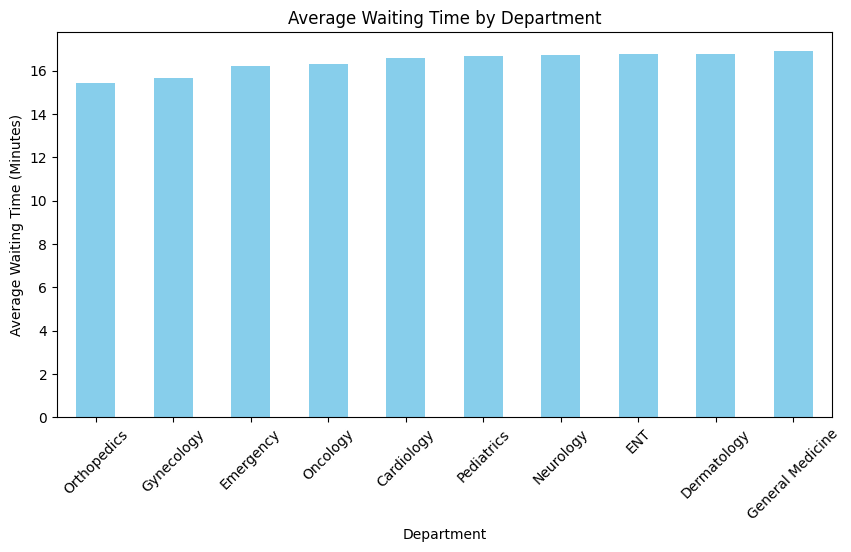

In [ ]:
import matplotlib.pyplot as plt

dept_wait = df.groupby('Department')['Waiting_Time_Min'].mean().sort_values()

plt.figure(figsize=(10,5))
dept_wait.plot(kind='bar', color='skyblue')
plt.title("Average Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (Minutes)")
plt.xticks(rotation=45)
plt.show()

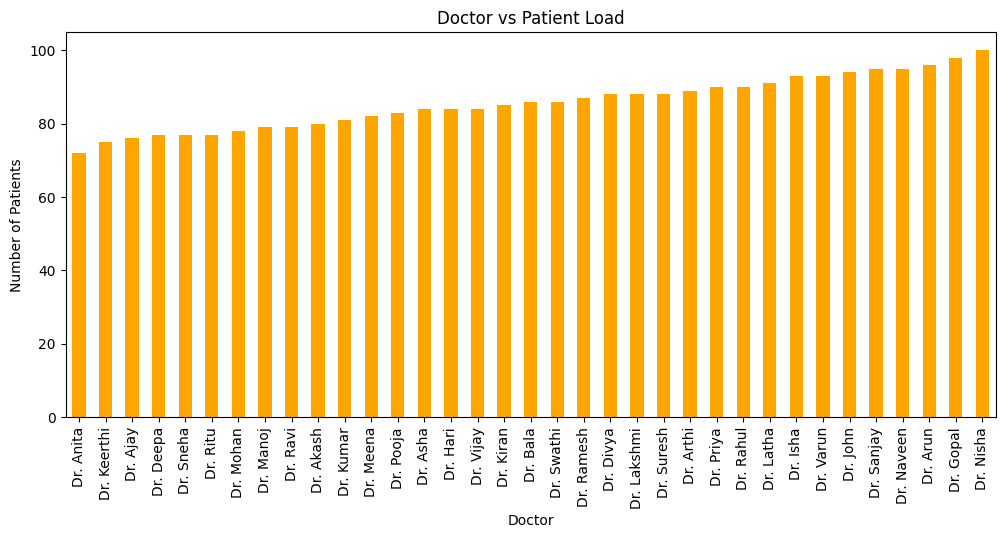

In [ ]:
doctor_load = df.groupby('Doctor')['Patient_ID'].count().sort_values()

plt.figure(figsize=(12,5))
doctor_load.plot(kind='bar', color='orange')
plt.title("Doctor vs Patient Load")
plt.xlabel("Doctor")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)
plt.show()

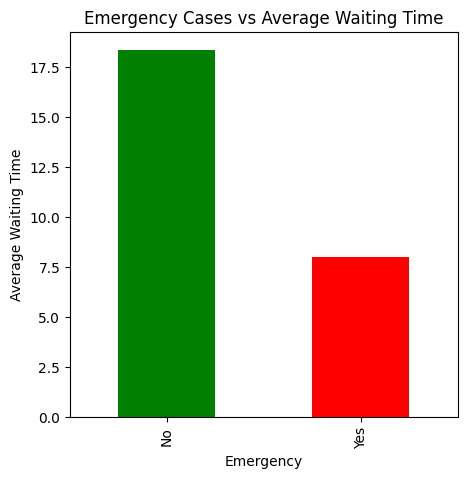

In [ ]:
emergency_wait = df.groupby('Emergency')['Waiting_Time_Min'].mean()

plt.figure(figsize=(5,5))
emergency_wait.plot(kind='bar', color=['green','red'])
plt.title("Emergency Cases vs Average Waiting Time")
plt.xlabel("Emergency")
plt.ylabel("Average Waiting Time")
plt.show()

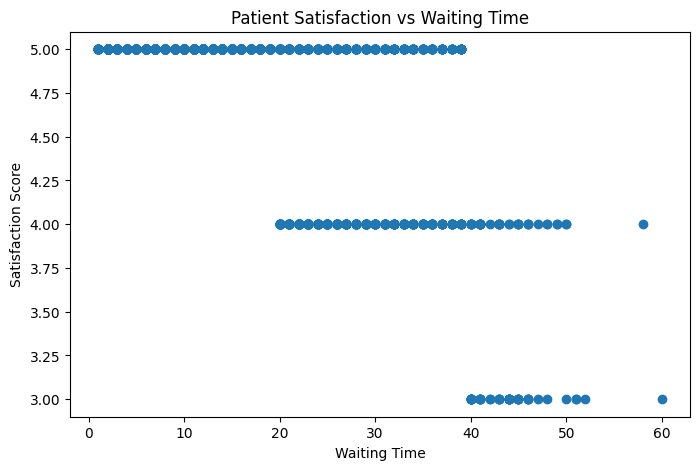

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Waiting_Time_Min'], df['Satisfaction_Score'])
plt.title("Patient Satisfaction vs Waiting Time")
plt.xlabel("Waiting Time")
plt.ylabel("Satisfaction Score")
plt.show()

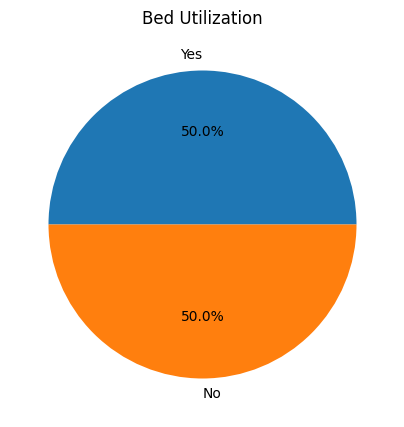

In [ ]:
bed = df['Bed_Assigned'].value_counts()

plt.figure(figsize=(5,5))
bed.plot(kind='pie', autopct='%1.1f%%')
plt.title("Bed Utilization")
plt.ylabel("")
plt.show()

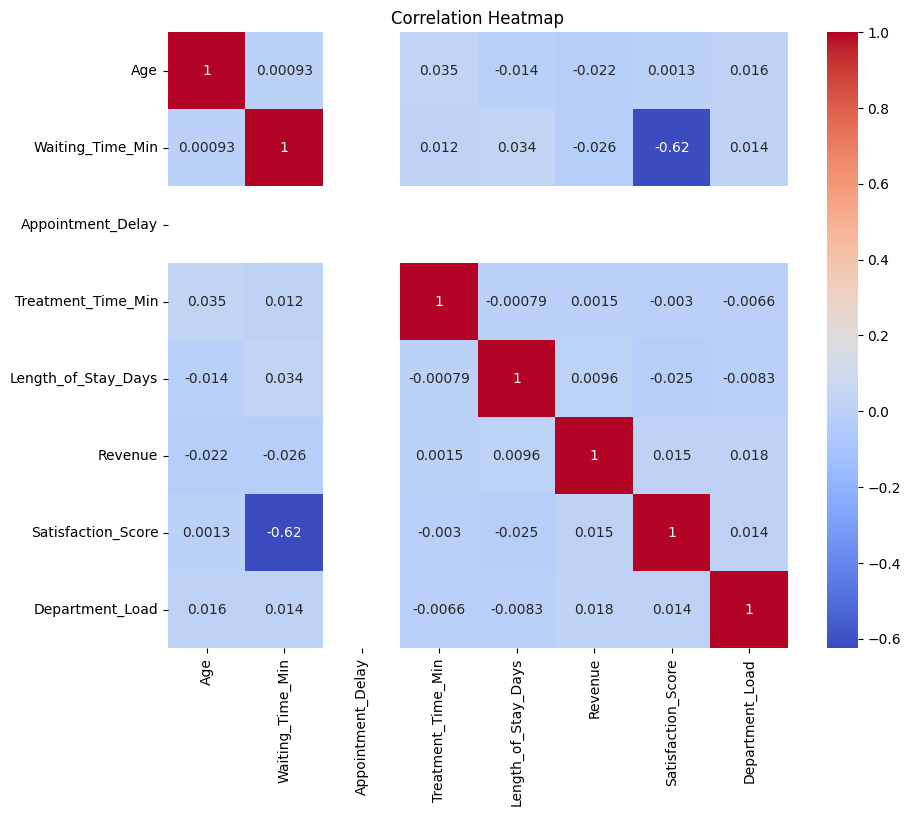

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

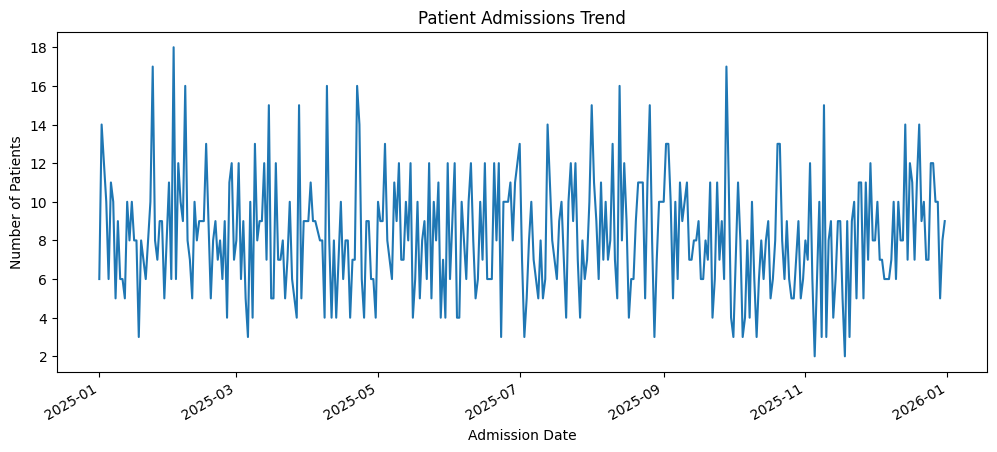

In [ ]:
patient_trend = df.groupby('Admission_Date')['Patient_ID'].count()

plt.figure(figsize=(12,5))
patient_trend.plot()
plt.title("Patient Admissions Trend")
plt.xlabel("Admission Date")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
df.to_csv("Cleaned_Hospital_Dataset.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import files
files.download("Cleaned_Hospital_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>